# Life-cycle OLG with borrowing constraints — the two-stage-loss model

The fourth `examples/` stop, and the one that motivated a new capability in the
framework. This is **Day 2, Exercise 4** of the Geneva 2026 *Deep Learning for
Economics & Finance* course: a 6-generation overlapping-generations economy
where households live $H = 6$ deterministic periods (one period $\approx$ 10
years, ages 20–80), save in capital subject to a **borrowing constraint**
$k^h_t \ge 0$, and supply age-dependent labor (less in the last two periods —
retirement).

Each working cohort $h \in \{0, \dots, H-2\}$ chooses a saving rate; the last
cohort consumes everything. The optimality condition is an intertemporal Euler
that holds with equality **only when the borrowing constraint is slack**:

$$\frac{1}{c^h_t} \;\ge\; \beta\,\mathbb{E}_t\!\left[\frac{1-\delta+r_{t+1}}{c^{h+1}_{t+1}}\right],
\qquad k^{h+1}_{t+1}\ge 0,\qquad \text{complementary slackness.}$$

We encode the complementarity with a Fischer-Burmeister residual, exactly as the
course notebook does.

## Why this model needed a new loss

The FB nonlinearity wraps an **expectation**. And $\mathbb{E}[f^{FB}(\cdot)] \ne
f^{FB}(\mathbb{E}[\cdot])$: averaging the residual over shocks and *then* squaring
(the standard DEQN path) puts the nonlinearity in the wrong place and leaves a
bias floor. So this model is trained with the framework's **two-stage loss**:

- `inside_fn` returns the shock-dependent continuation terms
  $(1-\delta+r')/c'^{\,j}$, which the loss averages to $\mathbb{E}[\cdot]$;
- `combine_fn` applies the Fischer-Burmeister **after** the expectation.

The standard $(\mathbb{E}[r])^2$ path is the special case `combine = identity`.
This is the architectural prize from the port: occasionally-binding constraints
**under uncertainty**, solved MC-correctly.

**Outline**
- 1 — Inspect the model
- 2 — Train (two-stage loss, no closed-form steady state)
- 3 — Loss curve
- 4 — Reproduce the Exercise-4 diagnostic panels
- 5 — Ergodic accuracy + the borrowing-constraint corner
- 6 — Summary

In [1]:
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

from deqn_jax.config import TrainConfig
from deqn_jax.models.olg_lifecycle import MODEL
from deqn_jax.models.olg_lifecycle.equations import _cohort_block, combine_fn, inside_fn
from deqn_jax.models.olg_lifecycle.variables import CONSTANTS, H, L_CYCLE
from deqn_jax.plots import plot_loss_curve
from deqn_jax.training.trainer import train_from_config

## 1. Inspect the model

State $\mathbf{x}_t = (Z_t,\, k^0_t, \dots, k^5_t)$ — TFP plus the capital held by
each age group (7 states). Policy is the saving rate out of cash-at-hand for the
five cohorts that still save (sigmoid-bounded to $(0,1)$, so consumption and
saved capital are both positive by construction). Five Euler conditions, one per
saving cohort.

There is **no closed-form steady state**; the cross-sectional capital
distribution and TFP are solved jointly over the ergodic distribution, seeded
from a random $\exp(\mathcal{U}(0,1))$ init — just like the course notebook.

In [2]:
print(f"states   : {MODEL.n_states}  {MODEL.state_names}")
print(f"policies : {MODEL.n_policies}  {MODEL.policy_names}")
print(f"equations: {len(MODEL.equation_names)}  {MODEL.equation_names}")
print(f"two-stage hooks present: inside_fn={MODEL.inside_fn is not None}, "
      f"combine_fn={MODEL.combine_fn is not None}")
print(f"steady_state_fn: {MODEL.steady_state_fn}  (None -> trained from random init)")
print()
print(f"alpha={CONSTANTS['alpha']}, beta={CONSTANTS['beta']:.4f} (=0.99^10), "
      f"delta={CONSTANTS['delta']}, rho_z={CONSTANTS['rho_z']:.4f}, sigma_z={CONSTANTS['sigma_z']}")
print(f"age-dependent labor l_cycle = {L_CYCLE}  (retirement in the last two periods)")

states   : 7  ('Z', 'k0', 'k1', 'k2', 'k3', 'k4', 'k5')
policies : 5  ('s0', 's1', 's2', 's3', 's4')
equations: 5  ('euler_0', 'euler_1', 'euler_2', 'euler_3', 'euler_4')
two-stage hooks present: inside_fn=True, combine_fn=True
steady_state_fn: None  (None -> trained from random init)

alpha=0.36, beta=0.9044 (=0.99^10), delta=0.8, rho_z=0.3487, sigma_z=0.1
age-dependent labor l_cycle = (1.0, 1.8, 2.3, 2.5, 1.6, 1.25)  (retirement in the last two periods)


## 2. Train

Recipe from `configs/olg_lifecycle.yaml`: a `[70, 70]` ReLU MLP with sigmoid
output (Simon's `10 * n_input` width), Adam at `3e-4`, MC expectation with
antithetic shocks. The two-stage path is selected automatically because the
model declares `inside_fn` + `combine_fn`. A few thousand episodes converge in
seconds on CPU.

In [3]:
cfg = TrainConfig.from_yaml("../configs/olg_lifecycle.yaml")
params, history = train_from_config(cfg)

DEQN-JAX Training
  Model:           olg_lifecycle
  Optimizer:       adam (lr=3e-04)
  Precision:       float32
  Network:         7 → 70 → 70 → 5
  Parameters:      5,885
  Batch size:      128
  Expectations:    8 MC samples
  Warm start:      no
  Schedule: 1 rollout (24×128=3072 states) → 1 epoch(s) × 1 minibatch(es) of 128 = 1 grad updates/cycle (3000 total over 3000 cycles)


  [ 200/3000] loss=2.25e-03 | grad=1.51e-02 | 78 ep/s
    euler_0  9.00e-03   euler_2  1.11e-04   euler_4  9.28e-04
    euler_1  1.18e-03   euler_3  3.85e-05


  [ 400/3000] loss=4.07e-04 | grad=4.95e-03 | 129 ep/s
    euler_0  1.60e-03   euler_2  6.90e-05   euler_4  4.98e-06
    euler_1  3.32e-04   euler_3  3.15e-05


  [ 600/3000] loss=1.03e-04 | grad=2.02e-03 | 166 ep/s
    euler_0  4.35e-04   euler_2  8.28e-06   euler_4  9.69e-06
    euler_1  5.36e-05   euler_3  9.27e-06


  [ 800/3000] loss=3.37e-05 | grad=6.28e-04 | 193 ep/s
    euler_0  1.46e-04   euler_2  6.63e-06   euler_4  5.17e-06
    euler_1  8.42e-06   euler_3  2.75e-06


...

  [2200/3000] loss=2.59e-06 | grad=1.01e-03 | 282 ep/s
    euler_0  7.81e-06   euler_2  2.15e-06   euler_4  7.47e-07
    euler_1  1.63e-06   euler_3  6.07e-07


  [2400/3000] loss=2.31e-06 | grad=1.70e-03 | 289 ep/s
    euler_0  6.01e-06   euler_2  2.49e-06   euler_4  9.76e-07
    euler_1  1.26e-06   euler_3  8.20e-07


  [2600/3000] loss=2.26e-06 | grad=1.59e-03 | 294 ep/s
    euler_0  5.06e-06   euler_2  2.31e-06   euler_4  6.74e-07
    euler_1  2.04e-06   euler_3  1.20e-06


  [2800/3000] loss=2.00e-06 | grad=2.17e-03 | 299 ep/s
    euler_0  4.13e-06   euler_2  3.20e-06   euler_4  8.86e-07
    euler_1  1.10e-06   euler_3  6.62e-07


  [3000/3000] loss=1.77e-06 | grad=8.63e-04 | 304 ep/s
    euler_0  3.98e-06   euler_2  2.29e-06   euler_4  8.92e-07
    euler_1  1.07e-06   euler_3  6.14e-07
Training complete in 9.9s (304 ep/s)
Final loss: 1.77e-06
    euler_0  3.98e-06   euler_2  2.29e-06   euler_4  8.92e-07
    euler_1  1.07e-06   euler_3  6.14e-07


## 3. Loss curve

The loss is the mean squared Fischer-Burmeister residual across the five Euler
conditions, with the expectation taken *inside* the FB.

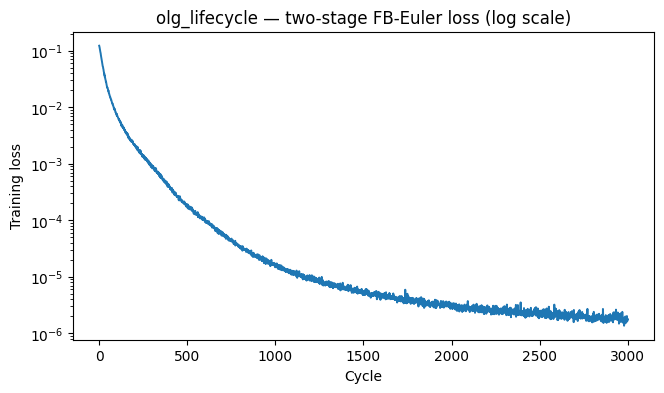

loss: 1.226e-01 -> 1.367e-06


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4))
plot_loss_curve(history, ax=ax, log_y=True)
ax.set_title("olg_lifecycle — two-stage FB-Euler loss (log scale)")
plt.show()
print(f"loss: {float(history['loss'][0]):.3e} -> {float(min(history['loss'][-50:])):.3e}")

## 4. Reproduce the Exercise-4 diagnostic panels

The course notebook reads a trained policy off by plotting, by age group, the
cross-sectional capital, consumption, cash-at-hand, relative Euler errors, the
saving policy, and the return distribution. We reproduce that exact panel set on
the deqn-jax solution.

First, simulate the ergodic distribution under the trained policy, then compute
the per-cohort quantities with the model's own `_cohort_block`. The per-cohort
**relative Euler error** is the MC-correct two-stage residual: average the
continuation terms over shocks, then apply FB (reusing `inside_fn` + `combine_fn`).

In [5]:
def simulate(params, key, n_traj=1024, T=80, burn=30):
    """Roll the trained policy forward; collect post-burn-in ergodic states."""
    s = MODEL.init_state_fn(key, n_traj, CONSTANTS)
    visited = []
    for t in range(T):
        key, sk = jr.split(key)
        eps = jr.normal(sk, (n_traj, 1))
        if t >= burn:
            visited.append(s)
        s = MODEL.step_fn(s, params(s), eps, CONSTANTS)
    return jnp.concatenate(visited, axis=0)


def ergodic_euler_error(params, X, key, n_shocks=64):
    """MC-correct per-cohort relative Euler error: E[inside] then FB."""
    insides = []
    for _ in range(n_shocks):
        key, sk = jr.split(key)
        eps = jr.normal(sk, (X.shape[0], 1))
        ns = MODEL.step_fn(X, params(X), eps, CONSTANTS)
        ins = inside_fn(X, params(X), ns, params(ns), CONSTANTS)
        insides.append(jnp.stack([ins[f"inside_{j}"] for j in range(H)], axis=1))
    E = jnp.mean(jnp.stack(insides), axis=0)
    Edict = {f"inside_{j}": E[:, j] for j in range(H)}
    res = combine_fn(X, params(X), Edict, CONSTANTS)
    return np.asarray(jnp.stack([res[f"euler_{h}"] for h in range(H - 1)], axis=1))


X = simulate(params, jr.PRNGKey(1))
Z, k = X[:, :1], X[:, 1 : 1 + H]
blk = _cohort_block(Z, k, params(X), CONSTANTS)
c, sav, cah, r = (np.asarray(blk[n]) for n in ("c", "sav", "cah", "r"))
k_np = np.asarray(k)
log_err = np.log10(np.abs(ergodic_euler_error(params, X, jr.PRNGKey(2))) + 1e-16)
print(f"ergodic sample: {X.shape[0]} states")

ergodic sample: 51200 states


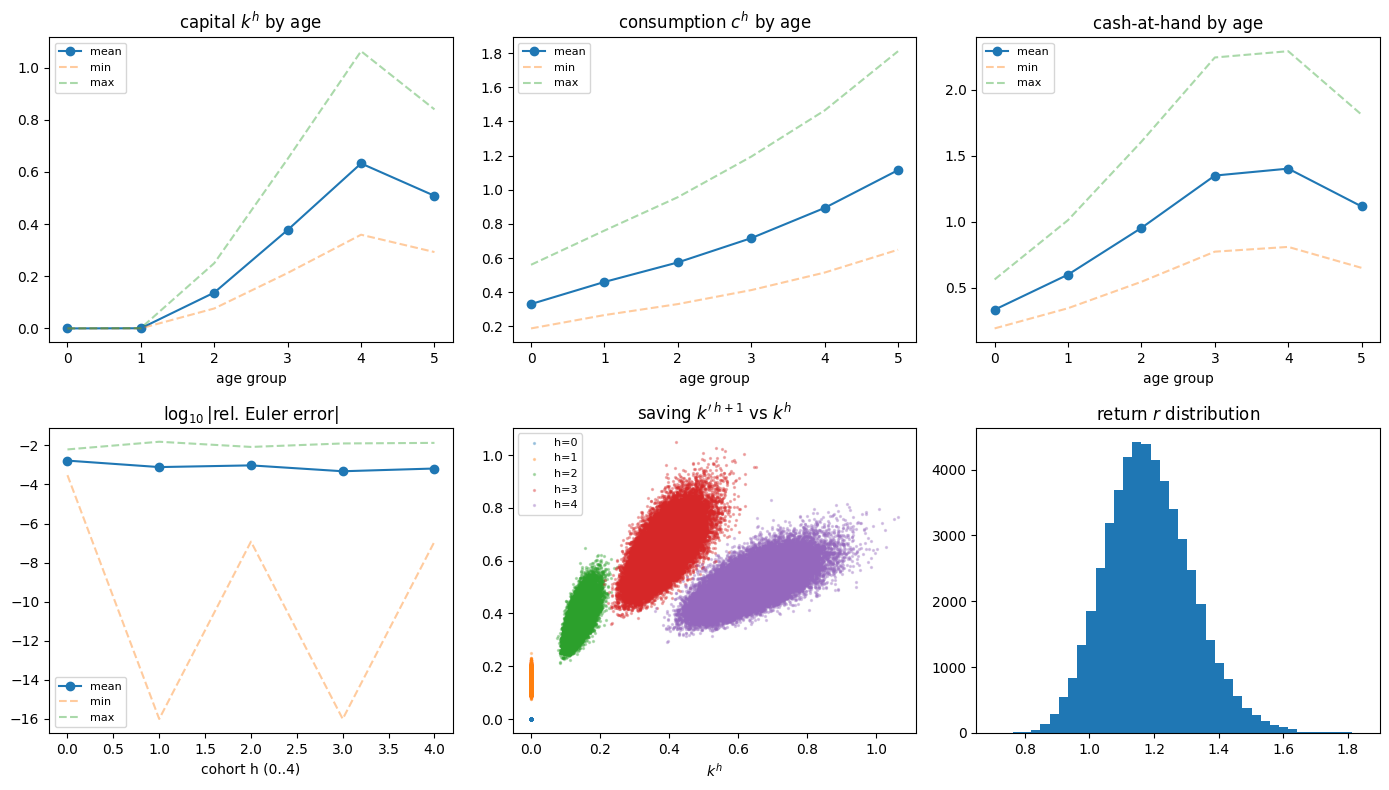

In [6]:
def band(ax, data, title, xl="age group"):
    a = np.arange(data.shape[1])
    ax.plot(a, data.mean(0), "o-", label="mean")
    ax.plot(a, data.min(0), "--", alpha=0.4, label="min")
    ax.plot(a, data.max(0), "--", alpha=0.4, label="max")
    ax.set_title(title); ax.set_xlabel(xl); ax.legend(fontsize=8)


fig, ax = plt.subplots(2, 3, figsize=(14, 8))
band(ax[0, 0], k_np, "capital $k^h$ by age")
band(ax[0, 1], c, "consumption $c^h$ by age")
band(ax[0, 2], cah, "cash-at-hand by age")
band(ax[1, 0], log_err, r"$\log_{10}|$rel. Euler error$|$", "cohort h (0..4)")
for h in range(H - 1):
    ax[1, 1].scatter(k_np[:, h], sav[:, h], s=2, alpha=0.3, label=f"h={h}")
ax[1, 1].set_title(r"saving $k'^{\,h+1}$ vs $k^h$"); ax[1, 1].set_xlabel("$k^h$")
ax[1, 1].legend(fontsize=8)
ax[1, 2].hist(r[:, 0], bins=40); ax[1, 2].set_title("return $r$ distribution")
fig.tight_layout()
plt.show()

The panels match the Exercise-4 reference: a **hump-shaped capital profile**
($k^0=0$ for the newborn, rising through working life, peaking near retirement,
then dissaved), a **smooth rising consumption** profile, and a saving policy that
clusters by cohort. This is the standard life-cycle picture the course notebook
produces — recovered here by the JAX port under the two-stage loss.

## 5. Ergodic accuracy + the borrowing-constraint corner

The mean per-cohort relative Euler error is the headline accuracy number. The
youngest cohort is hardest (it sits closest to the borrowing constraint, where
the FB kink lives); older cohorts are tighter.

In [7]:
print("mean log10 |rel. Euler error| by cohort h=0..4:")
print("  ", np.round(log_err.mean(0), 2))
print(f"\noverall mean log10|errREE| = {log_err.mean():.2f}  "
      f"(~{10**log_err.mean():.1e} relative)")
print()
print("mean capital by age :", np.round(k_np.mean(0), 3))
print("mean consumption    :", np.round(c.mean(0), 3))
near_bind = (sav[:, : H - 1] < 1e-2).mean(0)
print("frac near borrowing constraint (k' < 1e-2), cohort 0..4:", np.round(near_bind, 3))

mean log10 |rel. Euler error| by cohort h=0..4:
   [-2.78 -3.11 -3.02 -3.32 -3.18]

overall mean log10|errREE| = -3.08  (~8.3e-04 relative)

mean capital by age : [0.    0.001 0.137 0.377 0.632 0.508]
mean consumption    : [0.331 0.461 0.575 0.717 0.894 1.115]
frac near borrowing constraint (k' < 1e-2), cohort 0..4: [1. 0. 0. 0. 0.]


**On comparing to the reference.** This is a faithful reproduction of the
Geneva Day 2 Ex 4 *method and diagnostics*: same equilibrium conditions, same FB
complementarity, same decade calibration, same diagnostic panels. On a like-for-
like ergodic $|\text{err}_{REE}|$ the JAX port currently trails the original
TensorFlow reference by roughly a part in ten on the log scale (a known gap
tracked in the project notes, not a ship blocker) — the shapes and the
economics agree; the last fraction of a decimal of accuracy is the open item.

The model exposes nothing exotic to get here: standard MLP, sigmoid-bounded
saving rates for $0 < s < 1$ (hence $c>0$ and $k'\ge 0$ by construction), and the
two-stage `inside_fn`/`combine_fn` hooks that put the Fischer-Burmeister
**after** the expectation.

## Summary

- **Model**: 6-generation life-cycle OLG with borrowing constraints (Geneva Day 2
  Ex 4). 7 states, 5 saving-rate policies, 5 Fischer-Burmeister Euler conditions,
  no closed-form steady state.
- **Capability it unlocked**: the **two-stage expectation-inside-residual loss**.
  Because the FB wraps an expectation, $\mathbb{E}[f^{FB}] \ne f^{FB}(\mathbb{E})$;
  `inside_fn` averages the continuation terms and `combine_fn` applies the FB
  afterward. The standard $(\mathbb{E}[r])^2$ path is recovered as
  `combine = identity`.
- **Result**: textbook life-cycle behaviour (capital hump, consumption smoothing)
  with ergodic per-cohort Euler errors in the $10^{-2}$–$10^{-3}$ range,
  reproducing the course exercise's diagnostic panels.
- **No special tooling**: plain MLP + sigmoid bounds + the two model hooks; the
  trainer, loss, and `deqn_jax.plots` suite are all stock.

The companion model with a closed-form oracle is `examples/olg_analytic_6.ipynb`
(Krueger-Kubler 2004); the constrained-labor sibling is
`bm_labor_constrained` (Day 2 Ex 3).